# Analysis of FracMinHash sketching on short sequences

FracMinHash with a scaled parameter of $s$ retains on average one k-mer per $s$ distinct k-mers; so, for a collection of 1 million distinct k-mers, and $s=1000$, we would expect a sketch size of approximately 1000 hashes.

For short sequences, however, an important question is: how frequently will we fail to generate any hashes for a sequence of a given length? That is, for a sequence of length $L$, what is the likelihood that we fail to generate any hashes for $L$, such that $L$ would be undetectable in a sequence search?

This can be modeled theoretically (and in practice) using the probability distribution of the time between independent events where an "event" is the first hash being retained on a stream of random k-mers. This is an exponential distribution.

Below we show that, in practice, the sourmash/branchwater implementation of FracMinHash generates hashes from a stream of random k-mers at the expected rate, and that for a scaled factor of 1000, approximately 99.9% of sequences of length 5KB will have at least one hash, and hence 99.9% of exact matching sequences to that 5KB can be detected in a sequence search. Conversely,  ~36% of sequences less than 1KB in size will not have a hash generated for them and therefore will not be detectable.

In [1]:
import sourmash
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import expon
import polars as pl

In [2]:
DNA=['A', 'T', 'C', 'G']
def make_random_kmer(ksize):
    kmer = []
    for i in range(ksize):
        kmer.append(random.choice(DNA))
    return "".join(kmer)

make_random_kmer(5)

'TGGCC'

In [3]:
KSIZE=21
N_TRIALS = 1000

# create an e mpty FracMinHash sketch with the appropriate parameters
blank_mh = sourmash.MinHash(n=0, ksize=KSIZE, scaled=1000)

# run a thousand trials in which we use sourmash to sketch k-mers until
# we obtain a hash.
lengths = []
for i in range(N_TRIALS):
    if i % 100 == 0:
        print('...', i)

    mh = blank_mh.copy_and_clear()

    # generate k-mers until a hash is kept
    n = 0
    while not len(mh):
        mh.add_kmer(make_random_kmer(21))
        n += 1

    # track how long it took.
    lengths.append(n)
        

... 0
... 100
... 200
... 300
... 400
... 500
... 600
... 700
... 800
... 900


In [4]:
# transform the distribution of lengths into a cumulative sum.
# there is definitely a more efficient way to do this!
x = []
y = []
for i in range(max(lengths)):
    x.append(i)
    number_lt = len([ j for j in lengths if j < i ])
    y.append(number_lt / N_TRIALS)

Text(0, 0.5, 'fraction of sequences of this length with one hash')

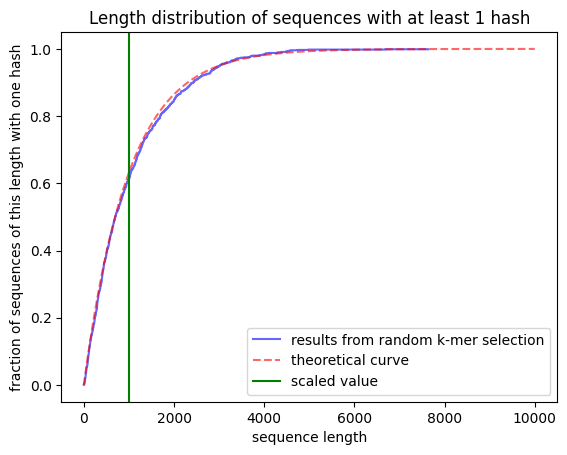

In [5]:
# plot, vs an exponential function

# the probability of an event is 1/1000
xx = np.array(range(0, 10000))
yy = expon.cdf(xx / 1000)

plt.plot(x, y, label='results from random k-mer selection', color='b', alpha=0.6)
plt.plot(xx, yy, color='r', linestyle='--', alpha=0.6, label='theoretical curve')
plt.axvline(1000, label='scaled value', linestyle='-', color='g')
plt.legend(loc='lower right')
plt.title('Length distribution of sequences with at least 1 hash')
plt.xlabel('sequence length')
plt.ylabel('fraction of sequences of this length with one hash')

## Calculate the sequence length for specific fractions

In [6]:
vals = []
for frac in (0.5, 0.64, 0.75, 0.9, 0.95, 0.99):
    vals.append(dict(frac=frac, ppf=int(expon.ppf(frac)*1000)))

ppf_df = pl.DataFrame(vals)
(ppf_df.style
 .cols_label(frac="fraction with one hash",
             ppf="sequence length (bp)")
)

fraction with one hash,sequence length (bp)
0.5,693
0.64,1021
0.75,1386
0.9,2302
0.95,2995
0.99,4605
